<font color="teal" size=9>Parametric experiments on GD</font>

- Learn how to setup and run parametric experiments
- Understand thimportance of starting values, learning rate, and training iterations, in GD.
- See that GD is an amazing algo but is NOT guranteed to give the correct answer.

So what we will do is:

<font color="lighblue">Repeat the model from the 1D video</font>

Conduct a one-variable experiment using (ie change one var at a time):
- Initial value
- Learning rate

Conduct a two-variable experiment using:

1. Learning rate AND training epochs




<font size=5>Running experiments to understand GD</font>

C:\Users\mpere\AppData\Local\Temp\ipykernel_24536\1941846942.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


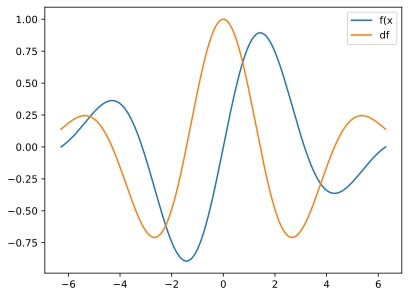

In [37]:
import numpy as np
import matplotlib.pyplot as plt 
import sympy as sym # sympy to compute the partial derivatives

from IPython import display 
display.set_matplotlib_formats('svg')


# the function and of course how we will provide input (linspace...)
x =  np.linspace(-2*np.pi,2*np.pi,401)
# sine wave multiplied by a gaussian
fx = np.sin(x) * np.exp(-x**2*.05)

# and it's derivative
df = np.cos(x)*np.exp(-x**2*.05) + np.sin(x)*(-.1*x)*np.exp(-x**2*.05)

# quick plot for inspection
plt.plot(x,fx,x,df)
plt.legend(['f(x','df'])


Starting point  1.29 1.29 0.88


C:\Users\mpere\AppData\Local\Temp\ipykernel_24536\3122550874.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')
C:\Users\mpere\AppData\Local\Temp\ipykernel_24536\3122550874.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f'Starting point  %.2f %.2f %.2f' %(startedHere,localmin,fx(startedHere)))


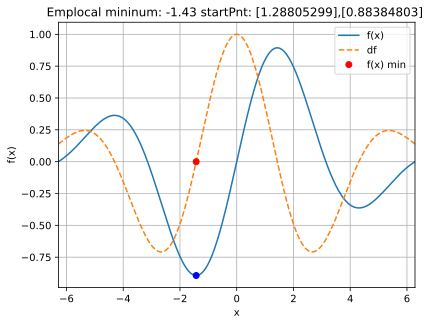

In [38]:
import numpy as np
import matplotlib.pyplot as plt 
import sympy as sym # sympy to compute the partial derivatives

from IPython import display 
display.set_matplotlib_formats('svg')
# x =  np.linspace(-2*np.pi,2*np.pi,401)

# function (note: over-writing variable names! not recommended) iow; getting rid of fcn in above cell for fx
def fx(x):
    return np.sin(x) * np.exp(-x**2*.05)

# derivative function
def deriv(x):
    return np.cos(x)*np.exp(-x**2*.05) - np.sin(x)*.1*x*np.exp(-x**2*.05)

# random starting point
localmin = np.random.choice(x,1) #np.array([6])
startedHere = localmin
print(f'Starting point  %.2f %.2f %.2f' %(startedHere,localmin,fx(startedHere)))
# learning parameters
learning_rate = 0.1
training_epochs = 1000

# run through training
for i in range(training_epochs):
    grad = deriv(localmin)
   # print('current localmin ' + str(localmin))
    localmin = localmin - learning_rate*grad

plt.plot(x,fx(x),x,deriv(x),'--')
plt.plot(localmin,deriv(localmin),'ro')
plt.plot(localmin,fx(localmin),'bo')
#plt.plot(startedHere,fx(startedHere),'g^')

#plt.plot(startedHere,fx(startedHere)+1,'bs')

plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['f(x)','df','f(x) min'])
plt.title('Emplocal mininum: %.2f startPnt: %s,%s '%(localmin[0],startedHere,fx(startedHere)))
plt.show()




<font color='teal' size=7>Run parametric experiments</font>

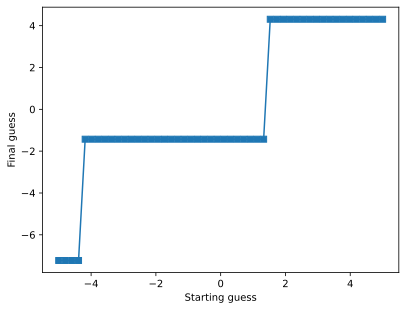

In [39]:

# Experiment 1: systematically varying the starting locations

startlocs = np.linspace(-5,5,50)
finalres = np.zeros(len(startlocs))

# loop over starting ponits
for idx,localmin in enumerate(startlocs):

    # run through training
    for i in range(training_epochs):
        grad = deriv(localmin)
        localmin = localmin - (learning_rate * grad)

    # store ethe final guess
    finalres[idx] = localmin

# Plot the results
plt.plot(startlocs,finalres,'s-')
plt.xlabel('Starting guess')
plt.ylabel('Final guess')
plt.show()
# The x-axis is the same as the above plot




We can see in the above plot we settle at 3 different values. Let's focus on the middle (longest horizontal bar) which is around -1.4 and +1.5. So now we can go back up and consult the graph and say, when we start our initial guess, when we force the initial guess to be anywhere between -4 and around 1.5, then... Well, it's pretty clear what's gonna happen from looking at this graph here.

It's clear that the function is gonna go down to the global minimum. But if we start over here, above 1.5, we end up at a local minimum of, you know, 4.5 or 4.4, whatever this minimum is here.

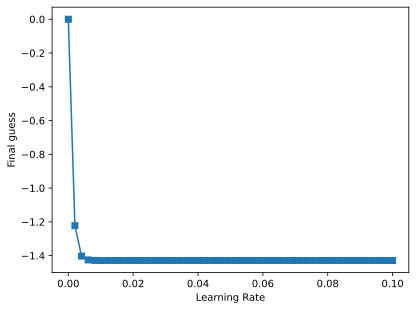

In [40]:
# Experiment 2: systematically varying the learning rate
# 10 to the minus 10, to 10 to minus 1 iow: (really really tiny, to very/respectably small)
learingrates = np.linspace(1e-10,1e-1,50)
finalres = np.zeros(len(learingrates))
# loop over learning rates
for idx,learingRate in enumerate(learingrates):

    # force starting guess to 0
    localmin = 0

    # run through training
    for i in range(training_epochs):
        grad = deriv(localmin)
        localmin = localmin - (learingRate*grad)

    # store the final guess
    finalres[idx] = localmin

plt.plot(learingrates,finalres,'s-')
plt.xlabel('Learning Rate')
plt.ylabel('Final guess')
plt.show()

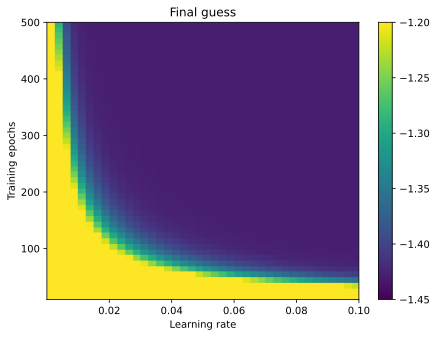

In [ ]:
# Experiment 3: Interaction between learning rate and training epochs
# import numpy as np
#setup parameters. we manipulting both it seems
learningrates = np.linspace(1e-10,1e-1,50)
training_epochs = np.round(np.linspace(10,500,40))
# init matrix to store results
finalres = np.zeros((len(learningrates),len(training_epochs)))

# loop over learning rates
for Lidx, learningRate in enumerate(learningrates):

    # loop fover training epochs
    for Eidx,trainEpochs in enumerate(training_epochs):
        localmin = 0 # fix the initial starting guess
        for i in range(int(trainEpochs)):
            grad = deriv(localmin)
            localmin = localmin - learningRate*grad
        # store thee final guess
        finalres[Lidx,Eidx] = localmin
# print(finalres)
# plot results
fig,ax = plt.subplots(figsize=(7,5))

plt.imshow(finalres,extent=[learningrates[0],learningrates[-1],training_epochs[0],training_epochs[-1]],aspect='auto',origin='lower',vmin=-1.45,vmax=-1.2)
plt.xlabel('Learning rate')
plt.ylabel('Training epochs')
plt.title('Final guess')
plt.colorbar()


# 

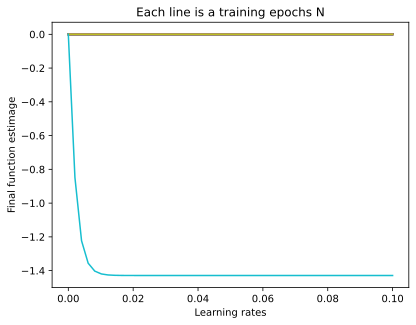

In [42]:
# another visualization
plt.plot(learningrates,finalres)
plt.xlabel('Learning rates')
plt.ylabel('Final function estimage')
plt.title('Each line is a training epochs N')
plt.show()